# Lagrange and Hermite Polynomial Interpolation

## Overview

Polynomial interpolation is one of the foundational problems in numerical analysis: given data $(x_0, f_0), \ldots, (x_n, f_n)$, find a polynomial $p$ of degree at most $n$ satisfying $p(x_i) = f_i$. This simple problem conceals surprising subtleties — the existence of a unique solution is guaranteed, but its accuracy as an approximation to the underlying function $f$ depends critically on the choice of nodes $\{x_i\}$.

## Lagrange Interpolation

The **Lagrange basis polynomials** provide an explicit construction of the interpolant. For nodes $x_0, \ldots, x_n$:
$$
L_i(x) = \prod_{j \neq i} \frac{x - x_j}{x_i - x_j}
$$
These satisfy $L_i(x_j) = \delta_{ij}$, so the unique interpolating polynomial is:
$$
p(x) = \sum_{i=0}^n f(x_i)\, L_i(x)
$$

## Hermite Interpolation

**Hermite interpolation** extends Lagrange interpolation by also matching derivative values. Given nodes $x_0, \ldots, x_n$ with function values $f_i = f(x_i)$ and derivative values $f'_i = f'(x_i)$, the Hermite interpolant matches all $2(n+1)$ conditions.

Using the **doubled-node trick**: define $z_0 = z_1 = x_0$, $z_2 = z_3 = x_1$, etc. The Hermite basis is:
$$
H_i(x) = \left[1 - 2(x - x_i) L_i'(x_i)\right] L_i(x)^2, \qquad
\tilde{H}_i(x) = (x - x_i) L_i(x)^2
$$
and the interpolant is:
$$
p(x) = \sum_{i=0}^n \left[f_i H_i(x) + f'_i \tilde{H}_i(x)\right]
$$

## Runge's Phenomenon

A central warning in polynomial approximation: high-degree interpolation on **equispaced nodes** often diverges at the boundaries, even for smooth functions. The canonical example is the **Runge function**:
$$
f(x) = \frac{1}{1 + 25x^2}, \quad x \in [-1, 1]
$$

## Chebyshev Nodes

**Chebyshev nodes** of the first kind are the roots of the Chebyshev polynomial $T_{n+1}(x) = \cos((n+1)\arccos x)$:
$$
x_k = \cos\!\left(\frac{(2k+1)\pi}{2(n+1)}\right), \quad k = 0, 1, \ldots, n
$$
They cluster at the endpoints, minimizing the Lebesgue constant and preventing Runge's phenomenon.

## What This Notebook Demonstrates

1. Lagrange interpolation with equispaced vs Chebyshev nodes on Runge's function
2. Hermite interpolation matching derivatives — comparison with Lagrange at the same number of nodes
3. Interactive degree slider
4. The Lebesgue constant as a measure of interpolation stability

### Setup

We build the interpolation algorithms from scratch using numpy, keeping them readable and pedagogically transparent.

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# Target function: Runge's function
def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def runge_prime(x):
    return -50.0 * x / (1.0 + 25.0 * x**2)**2

x_eval = np.linspace(-1, 1, 500)
f_exact = runge(x_eval)

print("Runge function and derivative defined.")
print(f"f(0) = {runge(0):.4f}, f(1) = {runge(1):.4f}")

Runge function and derivative defined.
f(0) = 1.0000, f(1) = 0.0385


### Lagrange Basis and Interpolant

The Lagrange basis polynomial $L_i$ is defined to be 1 at node $x_i$ and 0 at all other nodes:
$$
L_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^n \frac{x - x_j}{x_i - x_j}
$$
The interpolant is then $p(x) = \sum_i f_i L_i(x)$. We evaluate this using the **barycentric formula** for numerical stability:
$$
p(x) = \frac{\sum_i \frac{w_i}{x - x_i} f_i}{\sum_i \frac{w_i}{x - x_i}}
$$
where $w_i = \prod_{j \neq i} (x_i - x_j)^{-1}$ are the barycentric weights.

In [2]:
def barycentric_weights(nodes):
    """Compute barycentric weights w_i = 1 / prod_{j != i} (x_i - x_j)."""
    n = len(nodes)
    w = np.ones(n)
    for i in range(n):
        for j in range(n):
            if i != j:
                w[i] *= (nodes[i] - nodes[j])
    return 1.0 / w


def lagrange_interp(x_eval, nodes, values, weights=None):
    """Evaluate Lagrange interpolant at x_eval using barycentric formula."""
    if weights is None:
        weights = barycentric_weights(nodes)
    result = np.zeros_like(x_eval, dtype=float)
    for k, x in enumerate(x_eval):
        diffs = x - nodes
        # Check for exact node hit
        idx = np.where(np.abs(diffs) < 1e-14)[0]
        if len(idx) > 0:
            result[k] = values[idx[0]]
        else:
            wdiff = weights / diffs
            result[k] = np.dot(wdiff, values) / np.sum(wdiff)
    return result


def equispaced_nodes(n):
    """n+1 equispaced nodes on [-1,1]."""
    return np.linspace(-1, 1, n + 1)


def chebyshev_nodes(n):
    """n+1 Chebyshev nodes of the first kind on [-1,1]."""
    k = np.arange(n + 1)
    return np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))


print("Lagrange interpolation (barycentric) functions defined.")

Lagrange interpolation (barycentric) functions defined.


### Runge's Phenomenon: Equispaced vs Chebyshev Nodes

We compare the Lagrange interpolant for degree $n = 14$ (15 nodes) using equispaced and Chebyshev nodes. The interpolation error is bounded by:
$$
\|f - p_n\|_\infty \leq \frac{\|f^{(n+1)}\|_\infty}{(n+1)!} \cdot \|\omega_{n+1}\|_\infty
$$
where $\omega_{n+1}(x) = \prod_{i=0}^n (x - x_i)$. For equispaced nodes, $\|\omega_{n+1}\|_\infty$ grows exponentially. For Chebyshev nodes, $\|\omega_{n+1}\|_\infty = 2^{-n}$, the minimum possible value.

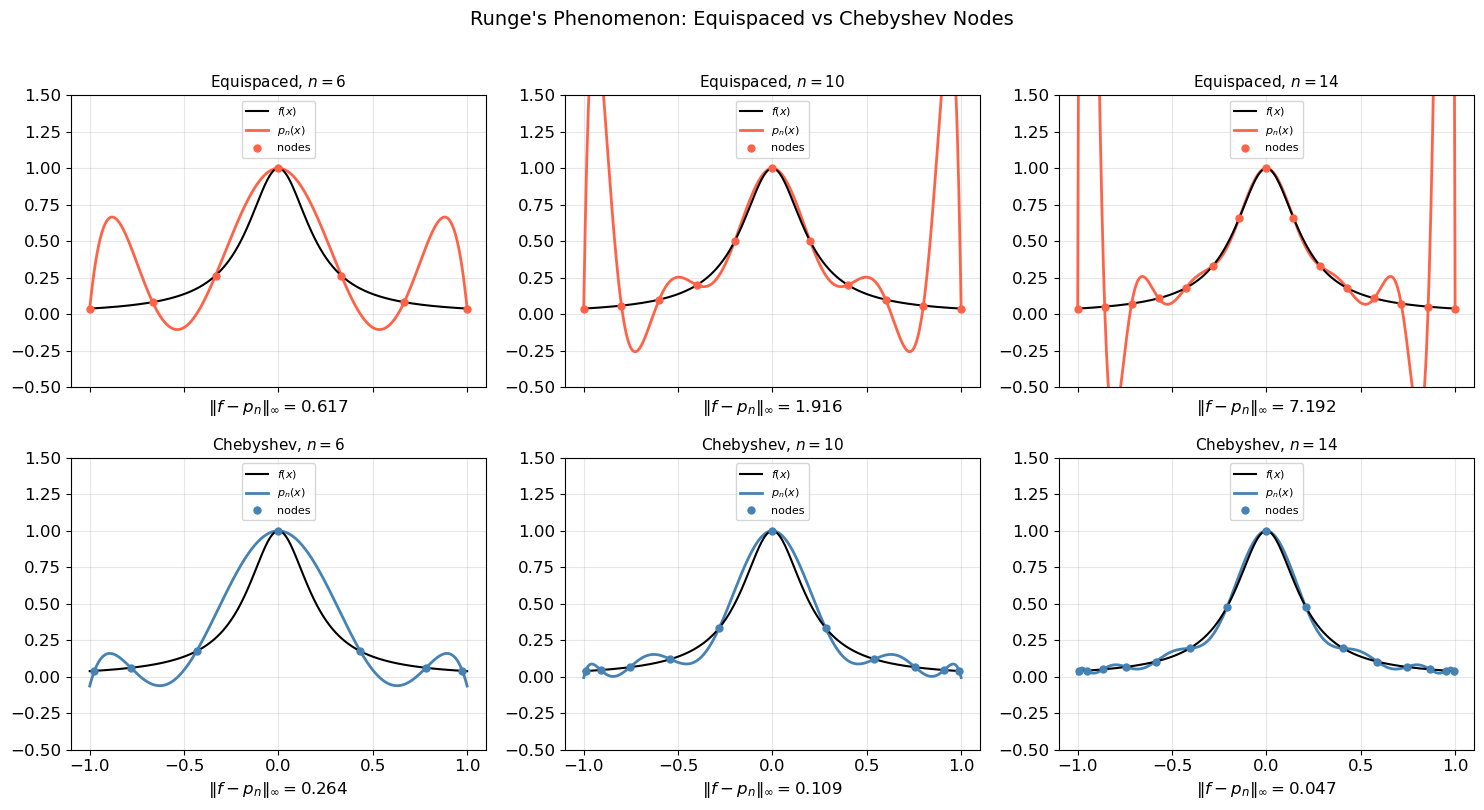

<Figure size 640x480 with 0 Axes>

In [3]:
degrees = [6, 10, 14]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for col, n in enumerate(degrees):
    nodes_eq = equispaced_nodes(n)
    nodes_ch = chebyshev_nodes(n)
    vals_eq = runge(nodes_eq)
    vals_ch = runge(nodes_ch)

    p_eq = lagrange_interp(x_eval, nodes_eq, vals_eq)
    p_ch = lagrange_interp(x_eval, nodes_ch, vals_ch)

    for row, (nodes, p_interp, title, color) in enumerate([
            (nodes_eq, p_eq, f"Equispaced, $n={n}$", 'tomato'),
            (nodes_ch, p_ch, f"Chebyshev, $n={n}$", 'steelblue')]):

        ax = axes[row, col]
        ax.plot(x_eval, f_exact, 'k-', lw=1.5, label='$f(x)$', zorder=3)
        ax.plot(x_eval, p_interp, '-', color=color, lw=2,
                label='$p_n(x)$', zorder=2)
        ax.plot(nodes, runge(nodes), 'o', color=color, ms=5,
                zorder=4, label='nodes')
        ax.set_ylim(-0.5, 1.5)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8, loc='upper center')
        ax.grid(True, alpha=0.3)
        err = np.max(np.abs(f_exact - p_interp))
        ax.set_xlabel(f'$\\|f-p_n\\|_\\infty = {err:.3f}$')

plt.suptitle("Runge's Phenomenon: Equispaced vs Chebyshev Nodes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.savefig("runge_comparison.png", dpi=80, bbox_inches='tight')
plt.show()

### Hermite Interpolation

Hermite interpolation at $n+1$ nodes matches both function values and first derivatives, giving $2(n+1)$ conditions and a polynomial of degree $\leq 2n+1$.

The basis functions are:
$$
H_i(x) = \big[1 - 2(x - x_i)L_i'(x_i)\big] L_i^2(x)
\qquad \tilde{H}_i(x) = (x - x_i)L_i^2(x)
$$
where $L_i'(x_i) = \sum_{j \neq i} \frac{1}{x_i - x_j}$.

With half as many nodes as a comparable Lagrange interpolant, Hermite interpolation achieves better accuracy because it also uses derivative information.

In [4]:
def hermite_interp(x_eval, nodes, f_vals, fp_vals):
    """
    Hermite interpolation at nodes, matching values f_vals and derivatives fp_vals.
    Returns polynomial of degree <= 2n+1 evaluated at x_eval.
    """
    n = len(nodes)

    # Compute L_i(x) for each node (naive product form)
    def L(i, x):
        val = np.ones_like(x, dtype=float)
        for j in range(n):
            if j != i:
                val *= (x - nodes[j]) / (nodes[i] - nodes[j])
        return val

    def L_prime_at_node(i):
        # L_i'(x_i) = sum_{j != i} 1/(x_i - x_j)
        s = 0.0
        for j in range(n):
            if j != i:
                s += 1.0 / (nodes[i] - nodes[j])
        return s

    result = np.zeros_like(x_eval, dtype=float)
    for i in range(n):
        Li = L(i, x_eval)
        Li2 = Li ** 2
        Lpi = L_prime_at_node(i)
        H_i = (1 - 2 * (x_eval - nodes[i]) * Lpi) * Li2
        Ht_i = (x_eval - nodes[i]) * Li2
        result += f_vals[i] * H_i + fp_vals[i] * Ht_i

    return result

## Match polynomial degree fairly

Hermite uses values and derivatives at fewer nodes; Lagrange uses values at twice as many nodes so both interpolants have comparable degree.

In [5]:
# Compare: Lagrange with n nodes vs Hermite with n/2 nodes
n_hermite = 7   # 7+1 = 8 nodes for Hermite -> 16 conditions, degree 15
n_lagrange = 15  # 16 nodes for Lagrange, same degree

nodes_h = chebyshev_nodes(n_hermite)
nodes_l = chebyshev_nodes(n_lagrange)

p_hermite = hermite_interp(x_eval, nodes_h, runge(nodes_h), runge_prime(nodes_h))
p_lagrange_16 = lagrange_interp(x_eval, nodes_l, runge(nodes_l))

## Compare approximants and maximum error

A common vertical scale makes endpoint oscillation and global error directly comparable.

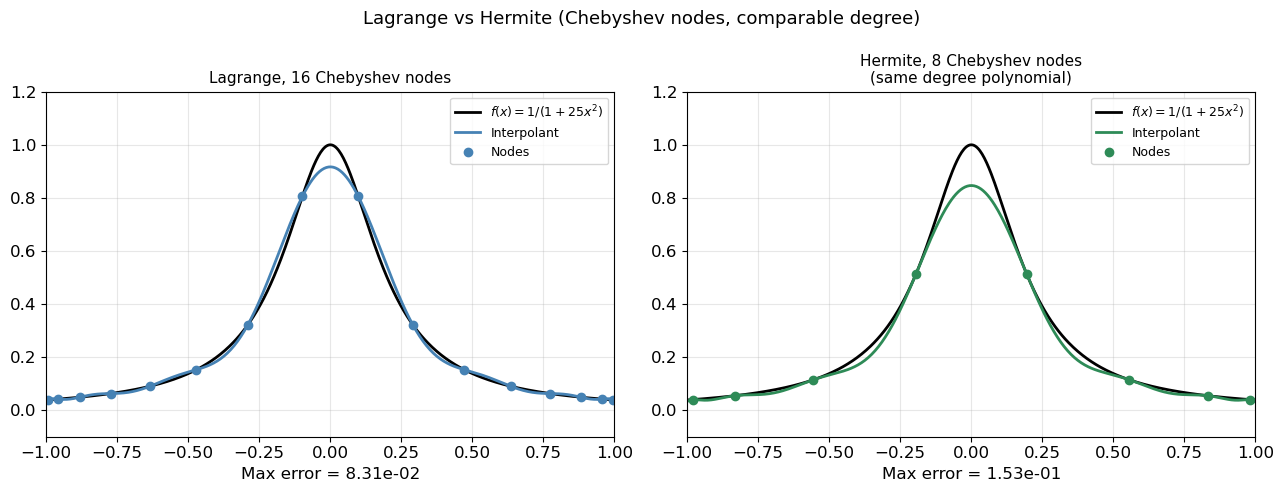

<Figure size 640x480 with 0 Axes>

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, p_interp, nodes_used, title, color in zip(
        axes,
        [p_lagrange_16, p_hermite],
        [nodes_l, nodes_h],
        [f'Lagrange, {n_lagrange+1} Chebyshev nodes',
         f'Hermite, {n_hermite+1} Chebyshev nodes\n(same degree polynomial)'],
        ['steelblue', 'seagreen']):

    ax.plot(x_eval, f_exact, 'k-', lw=2, label='$f(x) = 1/(1+25x^2)$')
    ax.plot(x_eval, p_interp, '-', color=color, lw=2, label='Interpolant')
    ax.plot(nodes_used, runge(nodes_used), 'o', color=color, ms=6, label='Nodes')
    ax.set_ylim(-0.1, 1.2)
    ax.set_xlim(-1, 1)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    err = np.max(np.abs(f_exact - p_interp))
    ax.set_xlabel(f'Max error = {err:.2e}')

plt.suptitle("Lagrange vs Hermite (Chebyshev nodes, comparable degree)", fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig("hermite_comparison.png", dpi=80, bbox_inches='tight')
plt.show()

### Lebesgue Constant

The **Lebesgue constant** measures the worst-case amplification of interpolation errors:
$$
\Lambda_n = \max_{x \in [-1,1]} \sum_{i=0}^n |L_i(x)|
$$
It controls the error via $\|f - p_n\|_\infty \leq (1 + \Lambda_n) E_n(f)$ where $E_n(f)$ is the best polynomial approximation error.

- For equispaced nodes: $\Lambda_n \sim 2^n / (e n \log n)$ — **exponential growth**
- For Chebyshev nodes: $\Lambda_n \sim \frac{2}{\pi} \log n + C$ — **logarithmic growth**

We compute the Lebesgue constant numerically for both node families across a range of degrees.

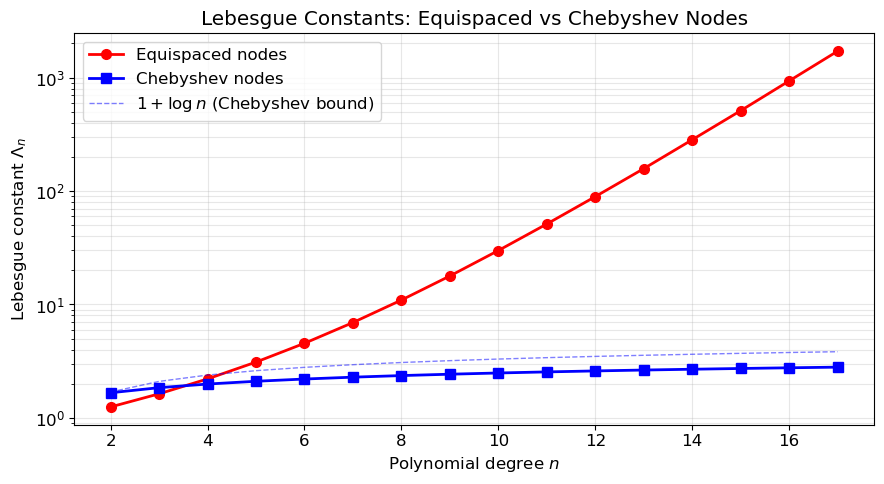

<Figure size 640x480 with 0 Axes>

In [7]:
def lebesgue_constant(nodes, x_eval):
    """Compute Lebesgue constant for given nodes."""
    n = len(nodes)
    lam_sum = np.zeros_like(x_eval)
    for i in range(n):
        Li = np.ones_like(x_eval)
        for j in range(n):
            if j != i:
                Li *= (x_eval - nodes[j]) / (nodes[i] - nodes[j])
        lam_sum += np.abs(Li)
    return np.max(lam_sum)


x_leb = np.linspace(-1, 1, 300)
degree_range = range(2, 18)
leb_eq = []
leb_ch = []

for n in degree_range:
    leb_eq.append(lebesgue_constant(equispaced_nodes(n), x_leb))
    leb_ch.append(lebesgue_constant(chebyshev_nodes(n), x_leb))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(list(degree_range), leb_eq, 'ro-', lw=2, ms=7, label='Equispaced nodes')
ax.semilogy(list(degree_range), leb_ch, 'bs-', lw=2, ms=7, label='Chebyshev nodes')
# Reference: log(n) growth
ns = np.array(list(degree_range), dtype=float)
ax.semilogy(ns, 1 + np.log(ns), 'b--', lw=1, alpha=0.5, label=r'$1 + \log n$ (Chebyshev bound)')
ax.set_xlabel('Polynomial degree $n$')
ax.set_ylabel('Lebesgue constant $\\Lambda_n$')
ax.set_title('Lebesgue Constants: Equispaced vs Chebyshev Nodes')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("lebesgue.png", dpi=80, bbox_inches='tight')
plt.show()

### Interactive Degree Slider

The widget below lets you sweep the interpolation degree $n$ and observe how the Lagrange interpolant (with equispaced or Chebyshev nodes) converges to or diverges from the Runge function. The slider controls $n$; toggle the checkbox to switch node families.

### Static Snapshot

This cell generates the snippet image: a four-panel figure comparing equispaced and Chebyshev nodes at two degrees, clearly illustrating Runge's phenomenon and its resolution.

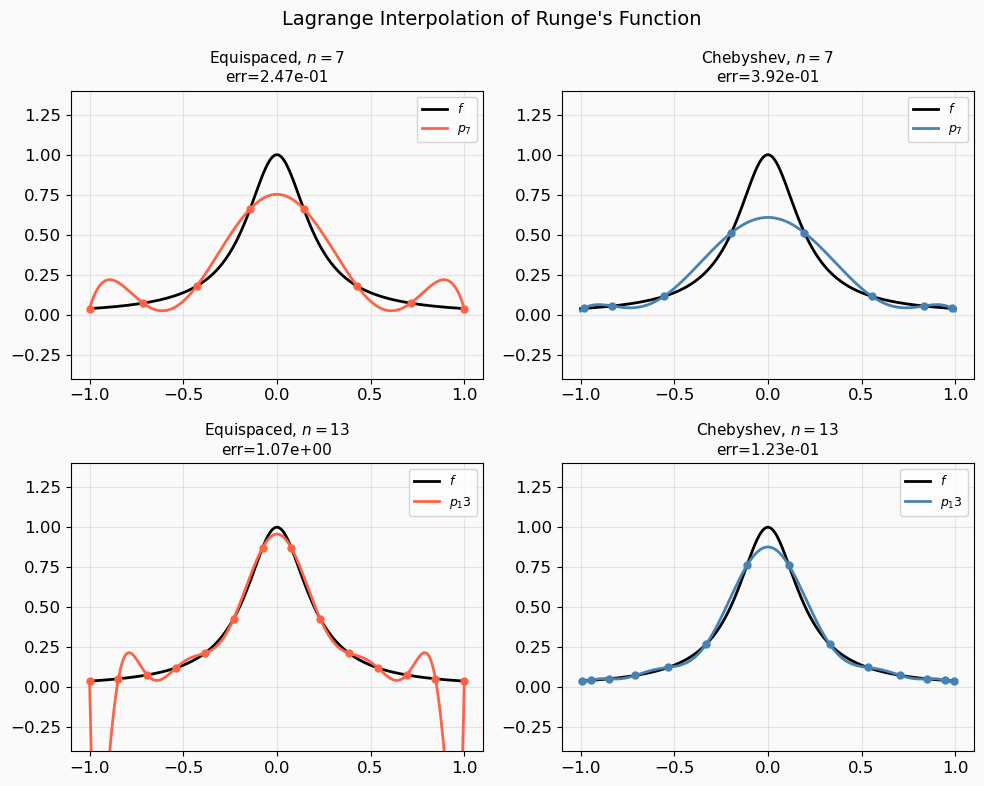

snippet.png saved.


In [8]:
STATIC_SNAPSHOT = True

if STATIC_SNAPSHOT:
    import matplotlib
    if 'get_ipython' not in globals():
        matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    fig_s, axes_s = plt.subplots(2, 2, figsize=(10, 8))
    fig_s.patch.set_facecolor('#fafafa')

    configs = [
        (7, equispaced_nodes, 'Equispaced', 'tomato'),
        (7, chebyshev_nodes, 'Chebyshev', 'steelblue'),
        (13, equispaced_nodes, 'Equispaced', 'tomato'),
        (13, chebyshev_nodes, 'Chebyshev', 'steelblue'),
    ]

    for ax, (n, node_fn, node_name, col) in zip(axes_s.flat, configs):
        nodes = node_fn(n)
        p = lagrange_interp(x_eval, nodes, runge(nodes))
        err = np.max(np.abs(f_exact - p))
        ax.plot(x_eval, f_exact, 'k-', lw=2, label='$f$')
        ax.plot(x_eval, p, '-', color=col, lw=2, label=f'$p_{n}$')
        ax.plot(nodes, runge(nodes), 'o', color=col, ms=5)
        ax.set_ylim(-0.4, 1.4)
        ax.set_title(f'{node_name}, $n={n}$\nerr={err:.2e}', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#fafafa')

    plt.suptitle("Lagrange Interpolation of Runge's Function", fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.savefig("snippet.png", dpi=100, bbox_inches='tight',
                facecolor=fig_s.get_facecolor())
    plt.close()
    print("snippet.png saved.")

## Takeaways

- The **Lagrange interpolant** through $n+1$ nodes is unique and given by the barycentric formula for numerical stability.
- **Runge's phenomenon** demonstrates that high-degree interpolation on equispaced nodes can diverge catastrophically, even for smooth functions. This is not a failure of polynomials but of the choice of nodes.
- **Chebyshev nodes** cluster near the endpoints and have the minimum possible $\|\omega_{n+1}\|_\infty = 2^{-n}$, controlling the interpolation error. Their Lebesgue constant grows only logarithmically.
- **Hermite interpolation** matches both function values and derivatives, achieving comparable accuracy with fewer nodes at the cost of needing derivative information.
- The Lebesgue constant quantifies interpolation stability: equispaced nodes yield exponential growth, while Chebyshev nodes yield logarithmic growth.

## Bibliography

- **Trefethen, L. N.** (2019). *Approximation Theory and Approximation Practice.* SIAM.
- **Burden, R. L. & Faires, J. D.** (2010). *Numerical Analysis.* Brooks/Cole.
- **Berrut, J.-P. & Trefethen, L. N.** (2004). *Barycentric Lagrange interpolation.* SIAM Review, 46(3), 501–517.
- **Runge, C.** (1901). *Über empirische Funktionen und die Interpolation zwischen äquidistanten Ordinaten.* Zeitschrift für Mathematik und Physik, 46, 224–243.